<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/VanillaCNN_Optimized_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


Using device: cuda
Beginning execution pipeline...
Files loaded successfully.
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 (DF Index: 477) | True: 1 | Pred: 0 | Confidence: 0.5243 | Uncertainty (Std): 0.0415
Sample 001 (DF Index: 837) | True: 1 | Pred: 1 | Confidence: 0.9998 | Uncertainty (Std): 0.0006
Sample 002 (DF Index: 302) | True: 1 | Pred: 1 | Confidence: 0.9579 | Uncertainty (Std): 0.0147
Sample 003 (DF Index: 405) | True: 0 | Pred: 0 | Confidence: 0.5658 | Uncertainty (Std): 0.0386
Sample 004 (DF Index: 333) | True: 1 | Pred: 1 | Confidence: 0.8974 | Uncertainty (Std): 0.0586
Sample 005 (DF Index: 332) | True: 1 | Pred: 1 | Confidence: 0.7957 | Uncertainty (Std): 0.0370
Sample 006 (DF Index: 886) | True: 0 | Pred: 1 | Confidence: 0.5013 | Uncertainty (Std): 0.1190
Sample 007 (DF Index: 730) | True: 0 | Pred: 0 | Confidence: 0.6068 | Uncertainty (Std): 0.0268
Sample 008 (DF Index: 775) | True: 0 | Pred: 1 | Confidence: 0.9474 | Uncertainty 

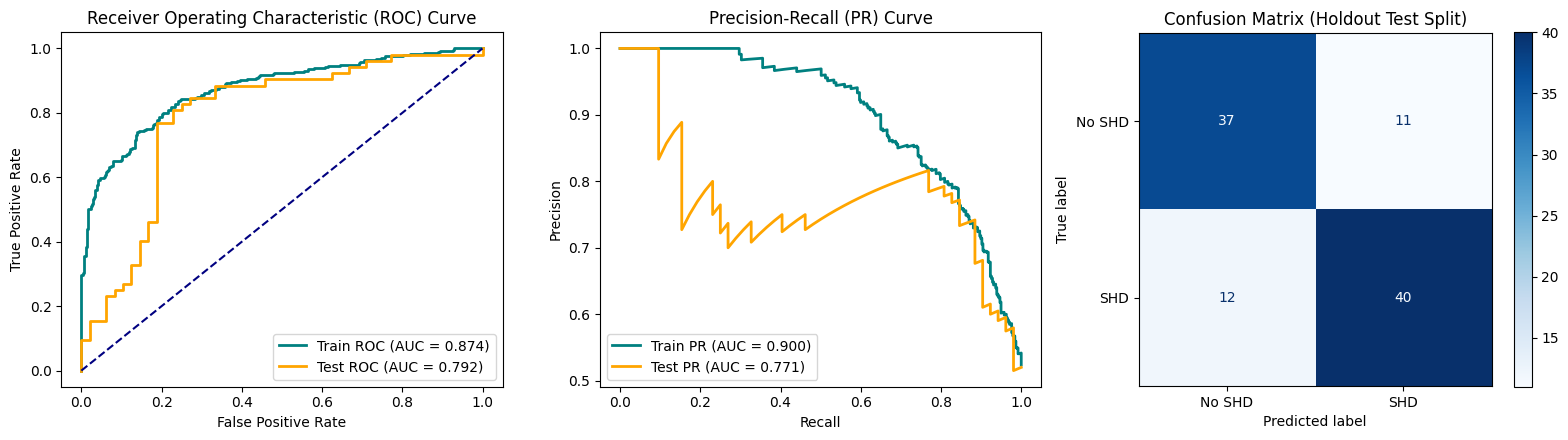

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

# Install blitz environment if not already present in the workspace
try:
    from blitz.modules import BayesianLinear, BayesianConv1d
    from blitz.utils import variational_estimator
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "blitz-bayesian-pytorch"])
    from blitz.modules import BayesianLinear, BayesianConv1d
    from blitz.utils import variational_estimator

# ──────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION & HYPERPARAMETERS
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PRIOR_SIGMA_1 = 2.0
PRIOR_SIGMA_2 = 0.0025
PRIOR_PI = 1.0
POSTERIOR_RHO_INIT = -5.0

CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS = ["age_at_ecg", "ventricular_rate", "atrial_rate", "pr_interval", "qrs_duration", "qt_corrected"]
ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS

ECG_SAMPLING_RATE_HZ = 500
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# ──────────────────────────────────────────────────────────────────────
# 1. SIGNAL PROCESSING & SIGNAL FILTERING
# ──────────────────────────────────────────────────────────────────────
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ, low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)
    return filtered.astype(np.float32)

# ──────────────────────────────────────────────────────────────────────
# 2. DEMOGRAPHIC PREPROCESSING
# ──────────────────────────────────────────────────────────────────────
def preprocess_demographics(df, scaler=None, imputer=None, categories=None, knn_k=5, fit=True):
    df = df[ALL_DEMO_COLS].copy()

    if categories is None:
        if not fit:
            raise ValueError("`categories` dictionary map must be provided when fit=False.")
        categories = {col: df[col].astype("category").cat.categories for col in CATEGORICAL_COLS}

    cat_codes = pd.DataFrame(index=df.index)
    for col in CATEGORICAL_COLS:
        cat_codes[col] = pd.Categorical(df[col], categories=categories[col]).codes
    cat_codes = cat_codes.replace(-1, np.nan)

    cont_part = df[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    if imputer is None:
        if not fit:
            raise ValueError("`imputer` object instance must be explicitly provided when fit=False.")
        imputer = KNNImputer(n_neighbors=knn_k)

    if fit:
        imputed = imputer.fit_transform(imputer_input)
    else:
        imputed = imputer.transform(imputer_input)

    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df.index)

    for col in CATEGORICAL_COLS:
        cats = categories[col]
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(cats) - 1)
        imputed_df[col] = pd.Categorical.from_codes(codes_rounded, categories=cats)

    ohe_df = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)
    feature_names = list(ohe_df.columns)

    if scaler is None:
        if not fit:
            raise ValueError("`scaler` must be provided when fit=False.")
        scaler = StandardScaler()

    cont_indices = [feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)

    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, imputer, categories, feature_names

# ──────────────────────────────────────────────────────────────────────
# 3. PYTORCH DATA STRUCTURING
# ──────────────────────────────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts, X_demo, y):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch across tensor targets."
        self.X_ts = torch.tensor(X_ts, dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 4. BAYESIAN NETWORK ARCHITECTURE
# ──────────────────────────────────────────────────────────────────────
class BayesianFiLMLayer(nn.Module):
    def __init__(self, demo_embed_dim, num_channels):
        super().__init__()
        self.film_proj = BayesianLinear(
            demo_embed_dim, 2 * num_channels,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )

    def forward(self, h, demo_embed):
        params = self.film_proj(demo_embed)
        gamma, beta = params.chunk(2, dim=-1)
        return gamma.unsqueeze(-1) * h + beta.unsqueeze(-1)

class BayesianFiLMConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, pool_size, demo_embed_dim, pool_type="avg"):
        super().__init__()
        self.conv = BayesianConv1d(
            in_channels, out_channels, kernel_size=kernel_size, padding=padding,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )
        self.bn = nn.BatchNorm1d(out_channels)
        self.film = BayesianFiLMLayer(demo_embed_dim, out_channels)
        self.act = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1) if pool_type == "gap" else nn.AvgPool1d(kernel_size=pool_size)

    def forward(self, x, demo_embed):
        return self.pool(self.act(self.film(self.bn(self.conv(x)), demo_embed)))

@variational_estimator
class BayesianHeartDiseaseNet(nn.Module):
    def __init__(self, sequence_length, in_channels, demo_dim, num_classes=2, demo_embed_dim=16):
        super().__init__()
        def blinear(in_f, out_f):
            return BayesianLinear(
                in_f, out_f, prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2,
                prior_pi=PRIOR_PI, posterior_rho_init=POSTERIOR_RHO_INIT
            )

        self.demo_encoder = nn.Sequential(blinear(demo_dim, demo_embed_dim), nn.ReLU())
        self.block1 = BayesianFiLMConvBlock(in_channels, 16, kernel_size=15, padding=7, pool_size=10, demo_embed_dim=demo_embed_dim, pool_type="avg")
        self.block2 = BayesianFiLMConvBlock(16, 32, kernel_size=9, padding=4, pool_size=10, demo_embed_dim=demo_embed_dim, pool_type="avg")
        self.block3 = BayesianFiLMConvBlock(32, 32, kernel_size=5, padding=2, pool_size=None, demo_embed_dim=demo_embed_dim, pool_type="gap")

        with torch.no_grad():
            dummy_ts = torch.zeros(1, in_channels, sequence_length)
            dummy_demo = torch.zeros(1, demo_embed_dim)
            x = self.block3(self.block2(self.block1(dummy_ts, dummy_demo), dummy_demo), dummy_demo)
            flat_sz = x.shape[1] * x.shape[2]

        self.head = nn.Sequential(nn.Flatten(), blinear(flat_sz, 32), nn.ReLU(), blinear(32, num_classes))

    def forward(self, x_ts, x_demo):
        demo_embed = self.demo_encoder(x_demo)
        return self.head(self.block3(self.block2(self.block1(x_ts, demo_embed), demo_embed), demo_embed))

# ──────────────────────────────────────────────────────────────────────
# 5. TRAINING ROUTINE
# ──────────────────────────────────────────────────────────────────────
def train_bayesian_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4, sample_nbr=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    n_train = len(train_loader.dataset)

    for epoch in range(epochs):
        model.train()
        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            X_ts_b += 0.05 * torch.randn_like(X_ts_b)

            optimizer.zero_grad()
            nll = 0.0
            for _ in range(sample_nbr):
                logits = model(X_ts_b, X_demo_b)
                nll += criterion(logits, y_b)

            loss = (nll / sample_nbr) + (model.nn_kl_divergence() / n_train)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_ts_v, X_demo_v, y_v in val_loader:
                X_ts_v, X_demo_v, y_v = X_ts_v.to(device), X_demo_v.to(device), y_v.to(device)
                probs_accum = sum(torch.softmax(model(X_ts_v, X_demo_v), dim=1) for _ in range(10)) / 10
                val_loss += criterion(torch.log(probs_accum + 1e-8), y_v).item() * X_ts_v.shape[0]
                val_total += X_ts_v.shape[0]

        scheduler.step(val_loss / val_total)

# ──────────────────────────────────────────────────────────────────────
# 6. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def get_predictions_and_labels(model, loader, sample_nbr=50):
    model.eval()
    all_probs, all_labels = [], []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            pass_logits = torch.stack([model(X_ts_b, X_demo_b) for _ in range(sample_nbr)], dim=0)
            pass_probs = torch.softmax(pass_logits, dim=-1)
            mean_probs = pass_probs.mean(dim=0)

            all_nll += criterion(torch.log(mean_probs + 1e-8), y_b.to(device)).item()
            all_probs.extend(mean_probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_labels), all_nll / len(loader.dataset)

def generate_and_display_comparative_metrics(model, train_loader, test_loader, sample_nbr=50):
    train_probs, train_labels, train_nll = get_predictions_and_labels(model, train_loader, sample_nbr)
    test_probs, test_labels, test_nll = get_predictions_and_labels(model, test_loader, sample_nbr)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. ROC Curves
    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    # 2. Precision-Recall Curves
    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    # 3. Test Confusion Matrix
    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 7. EXECUTION PIPELINE EXECUTION
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    ecg_path = 'ECG_waveforms_1K.npy'
    echo_path = 'EchoNext_EchoData_5K.csv'

    X_raw, echo_df = None, None
    max_retries, retry_delay = 5, 5

    for attempt in range(max_retries):
        try:
            if not os.path.exists(ecg_path) or not os.path.exists(echo_path):
                raise FileNotFoundError("Required files missing from space.")
            X_raw = np.load(ecg_path)[:1000]
            echo_df = pd.read_csv(echo_path).iloc[:1000].reset_index(drop=True)
            print("Files loaded successfully.")
            break
        except Exception as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed: {e}. Retrying...")
            time.sleep(retry_delay)
    else:
        raise RuntimeError("Failed to load required data files after multiple retries.")

    y_raw = echo_df['shd_moderate_or_greater_flag'].to_numpy()

    X_filtered = np.array([bandpass_filter_ecg(x, fs=250) for x in X_raw])
    X_ts = np.swapaxes(X_filtered, 1, 2)

    total_indices = np.arange(len(y_raw))
    rem_indices, test_indices = train_test_split(total_indices, test_size=0.10, random_state=RANDOM_SEED, stratify=y_raw)
    train_indices, val_indices = train_test_split(rem_indices, test_size=0.20, random_state=RANDOM_SEED, stratify=y_raw[rem_indices])

    demo_df_train_val = echo_df.iloc[rem_indices].copy()
    demo_df_test = echo_df.iloc[test_indices].copy()

    X_demo_train_val, scaler, imputer, categories, feature_names = preprocess_demographics(demo_df_train_val, fit=True)
    X_demo_test, _, _, _, _ = preprocess_demographics(demo_df_test, scaler=scaler, imputer=imputer, categories=categories, fit=False)

    rem_global_to_local_map = {global_idx: local_idx for local_idx, global_idx in enumerate(rem_indices)}
    train_local_indices_in_X_demo_train_val = [rem_global_to_local_map[idx] for idx in train_indices]
    val_local_indices_in_X_demo_train_val = [rem_global_to_local_map[idx] for idx in val_indices]

    X_demo_train = X_demo_train_val[train_local_indices_in_X_demo_train_val]
    X_demo_val = X_demo_train_val[val_local_indices_in_X_demo_train_val]
    X_ts_train, X_ts_val, X_ts_test = X_ts[train_indices], X_ts[val_indices], X_ts[test_indices]
    y_train, y_val, y_test = y_raw[train_indices], y_raw[val_indices], y_raw[test_indices]

    train_loader = DataLoader(FusedDataset(X_ts_train, X_demo_train, y_train), batch_size=32, shuffle=False)
    val_loader = DataLoader(FusedDataset(X_ts_val, X_demo_val, y_val), batch_size=128, shuffle=False)
    test_loader = DataLoader(FusedDataset(X_ts_test, X_demo_test, y_test), batch_size=128, shuffle=False)

    model = BayesianHeartDiseaseNet(
        sequence_length=X_ts.shape[2], in_channels=X_ts.shape[1],
        demo_dim=X_demo_train.shape[1], num_classes=2, demo_embed_dim=32
    )

    print("Training model...")
    train_bayesian_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4)

    torch.manual_seed(RANDOM_SEED)

    print("\n===== Individual Test Sample Inference Profiles ====")
    model.eval()
    sample_counter = 0

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in test_loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            pass_logits = torch.stack([model(X_ts_b, X_demo_b) for _ in range(50)], dim=0)
            pass_probs = torch.softmax(pass_logits, dim=-1).cpu().numpy()

            mean_probs = pass_probs.mean(axis=0)
            std_probs = pass_probs.std(axis=0)

            for idx in range(X_ts_b.size(0)):
                true_val = y_b[idx].item()
                pred_val = np.argmax(mean_probs[idx])
                confidence = mean_probs[idx][pred_val]
                uncertainty = std_probs[idx][pred_val]
                global_df_idx = test_indices[sample_counter]

                print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | "
                      f"True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f} | Uncertainty (Std): {uncertainty:.4f}")
                sample_counter += 1

    generate_and_display_comparative_metrics(model, train_loader, test_loader, sample_nbr=50)